In [25]:
import sys
import os
import random
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
from matplotlib.gridspec import GridSpec

PROJECT_ROOT = os.path.dirname(os.path.dirname(os.path.abspath("__file__")))

In [26]:
BG        = "#080C14"
CARD      = "#0E1520"
BORDER    = "#1A2535"
TEXT      = "#E8F4FF"
MUTED     = "#5A7A9A"
ACCENT    = "#00D4FF"
GOLD      = "#FFD166"
SILVER    = "#C0C0C0"
BRONZE    = "#CD7F32"
PALETTE   = [GOLD, SILVER, BRONZE]

plt.rcParams.update({
    "figure.facecolor":  BG,
    "axes.facecolor":    CARD,
    "axes.edgecolor":    BORDER,
    "axes.labelcolor":   MUTED,
    "axes.titlecolor":   TEXT,
    "axes.titlesize":    13,
    "axes.titleweight":  "bold",
    "axes.titlepad":     14,
    "axes.grid":         True,
    "grid.color":        BORDER,
    "grid.linewidth":    0.6,
    "xtick.color":       MUTED,
    "ytick.color":       MUTED,
    "xtick.labelsize":   9,
    "ytick.labelsize":   9,
    "text.color":        TEXT,
    "legend.facecolor":  CARD,
    "legend.edgecolor":  BORDER,
    "legend.fontsize":   9,
    "font.family":       "monospace",
})

In [27]:
def parse_time(series):
    """Convert 'M:SS.ss' or 'SS.ss' strings to float seconds."""
    def _parse(val):
        if pd.isna(val):
            return np.nan
        s = str(val).strip()
        if ":" in s:
            parts = s.split(":")
            return float(parts[0]) * 60 + float(parts[1])
        try:
            return float(s)
        except ValueError:
            return np.nan
    return series.apply(_parse)


def fmt_time(secs):
    if pd.isna(secs):
        return "—"
    if secs >= 60:
        m = int(secs // 60)
        s = secs % 60
        return f"{m}:{s:05.2f}"
    return f"{secs:.2f}s"

In [28]:
df = pd.read_csv(os.path.join(PROJECT_ROOT, 'data', '2-cleaned_data', 'swimming.csv'))
df["Rank"]    = pd.to_numeric(df["Rank"], errors="coerce")
df["Results"] = parse_time(df["Results"])

In [29]:
# Best athletes
def chart_athletes(ax, df):
    """Bar chart: average rank per athlete, min 3 appearances, top 15."""
    df_valid = df[df["Rank"].notna() & (df["Rank"] != "") & (df["Rank"] != 0)].copy()
    df_valid["Rank"] = pd.to_numeric(df_valid["Rank"], errors="coerce")
    df_valid = df_valid.dropna(subset=["Rank", "Athlete"])

    stats = (
        df_valid.groupby("Athlete")
        .agg(avg_rank=("Rank", "mean"), appearances=("Rank", "count"))
        .reset_index()
    )
    stats = stats[stats["appearances"] >= 3].sort_values("avg_rank").head(15)

    if stats.empty:
        ax.text(0.5, 0.5, "Not enough data\n(min 3 appearances per athlete)",
                ha="center", va="center", transform=ax.transAxes, color=MUTED)
        return

    # colour by avg rank bracket
    def bar_color(r):
        if r <= 1.5: return GOLD
        if r <= 2.5: return SILVER
        if r <= 3.5: return BRONZE
        return ACCENT

    colors = [bar_color(r) for r in stats["avg_rank"]]

    bars = ax.barh(stats["Athlete"], stats["avg_rank"], color=colors,
                   height=0.65, zorder=3)

    # value labels
    for bar, val, app in zip(bars, stats["avg_rank"], stats["appearances"]):
        ax.text(bar.get_width() + 0.05, bar.get_y() + bar.get_height() / 2,
                f"#{val:.2f}  ({app}×)",
                va="center", ha="left", fontsize=8, color=MUTED)

    ax.axvline(1, color=GOLD,   lw=0.8, ls="--", alpha=0.5, zorder=2)
    ax.axvline(3, color=BRONZE, lw=0.8, ls="--", alpha=0.4, zorder=2)

    ax.invert_xaxis()
    ax.set_xlabel("Average placement  (lower = better)")
    ax.set_title("Most Performant Athletes\nAvg placement · min. 3 appearances")
    ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda v, _: f"#{int(v)}" if v == int(v) else f"#{v:.1f}"))
    ax.tick_params(axis="y", labelsize=9)

In [30]:

def chart_countries(ax, df):
    """Stacked bar: podium medals per country (Gold / Silver / Bronze)."""
    df_valid = df.copy()
    df_valid["Rank"] = pd.to_numeric(df_valid["Rank"], errors="coerce")
    podium = df_valid[df_valid["Rank"].isin([1, 2, 3])].copy()
    podium["Medal"] = podium["Rank"].map({1: "Gold", 2: "Silver", 3: "Bronze"})

    if podium.empty:
        ax.text(0.5, 0.5, "No podium data found",
                ha="center", va="center", transform=ax.transAxes, color=MUTED)
        return

    medal_counts = (
        podium.groupby(["Team", "Medal"])
        .size()
        .unstack(fill_value=0)
        .reindex(columns=["Gold", "Silver", "Bronze"], fill_value=0)
    )
    medal_counts["total"] = medal_counts.sum(axis=1)
    medal_counts = medal_counts.sort_values(["Gold", "Silver", "Bronze"], ascending=False).head(15)
    medal_counts = medal_counts.drop(columns="total")

    medal_counts.plot(
        kind="barh", stacked=True, ax=ax,
        color=[GOLD, SILVER, BRONZE], width=0.65, zorder=3
    )

    ax.set_xlabel("Number of podium places")
    ax.set_title("Countries — Cumulative Podiums\nGold · Silver · Bronze")
    ax.legend(loc="lower right", framealpha=0.3)
    ax.tick_params(axis="y", labelsize=9)

In [31]:

def chart_time_evolution(ax, df):
    """Line chart: best winning time per Olympic edition for a random stroke × distance."""
    df_valid = df.copy()
    df_valid = df_valid.dropna(subset=["Rank", "Results", "Year"])

    winners = df_valid[df_valid["Rank"] == 1]

    # pick combos that have at least 4 data points
    combos = (
        winners.groupby(["Gender", "Stroke", "Distance"])
        .filter(lambda g: len(g) >= 4)
        [["Gender", "Stroke", "Distance"]].drop_duplicates()
    )

    if combos.empty:
        ax.text(0.5, 0.5, "Not enough data for trend chart",
                ha="center", va="center", transform=ax.transAxes, color=MUTED)
        return

    chosen = combos.sample(1, random_state=random.randint(0, 9999)).iloc[0]
    gender, stroke, distance = chosen["Gender"], chosen["Stroke"], chosen["Distance"]
    print(f"  → Time evolution: {gender} · {distance} {stroke}")

    subset = (
        winners[
            (winners["Gender"] == gender) &
            (winners["Stroke"] == stroke) &
            (winners["Distance"] == distance)
        ]
        .groupby("Year")["Results"].min()
        .reset_index()
        .sort_values("Year")
    )

    # linear regression trend
    x = subset["Year"].values
    y = subset["Results"].dropna().values
    print(subset["Results"])
    z = np.polyfit(x, y, 1)
    p = np.poly1d(z)
    x_trend = np.linspace(x.min(), x.max(), 200)

    ax.plot(x_trend, p(x_trend), color=MUTED, lw=1.2, ls="--", alpha=0.55, label="Trend", zorder=2)
    ax.plot(x, y, color=ACCENT, lw=2.2, marker="o", markersize=7,
            markerfacecolor=BG, markeredgewidth=2.2, markeredgecolor=ACCENT,
            label="Best time", zorder=3)

    # annotate each point
    for _, row in subset.iterrows():
        ax.annotate(fmt_time(row["Results"]),
                    (row["Year"], row["Results"]),
                    textcoords="offset points", xytext=(0, 10),
                    ha="center", fontsize=7.5, color=TEXT, alpha=0.85)

    # project to 2028
    projected = p(2028)
    ax.scatter([2028], [projected], color=GOLD, s=80, zorder=5, label=f"2028 projection: {fmt_time(projected)}")
    ax.axvline(2028, color=GOLD, lw=0.8, ls=":", alpha=0.6)

    improvement = ((y[0] - y[-1]) / y[0]) * 100
    ax.set_xlabel("Olympic edition")
    ax.set_ylabel("Time (seconds)")
    ax.set_title(f"Best Winning Time — {gender} · {distance} {stroke}\n"
                 f"Overall improvement: {improvement:.1f}%  ·  2028 projection shown")
    ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda v, _: fmt_time(v)))
    ax.legend(framealpha=0.3)
    ax.set_xlim(x.min() - 2, 2032)



Building charts...
  → Time evolution: Men · 100.0 Butterfly
0     55.90
1     54.27
2     54.35
3     54.92
4     53.08
5     53.00
6     53.32
7     52.27
8     52.00
9     51.25
10    50.58
11    51.21
12    50.39
13    49.45
Name: Results, dtype: float64


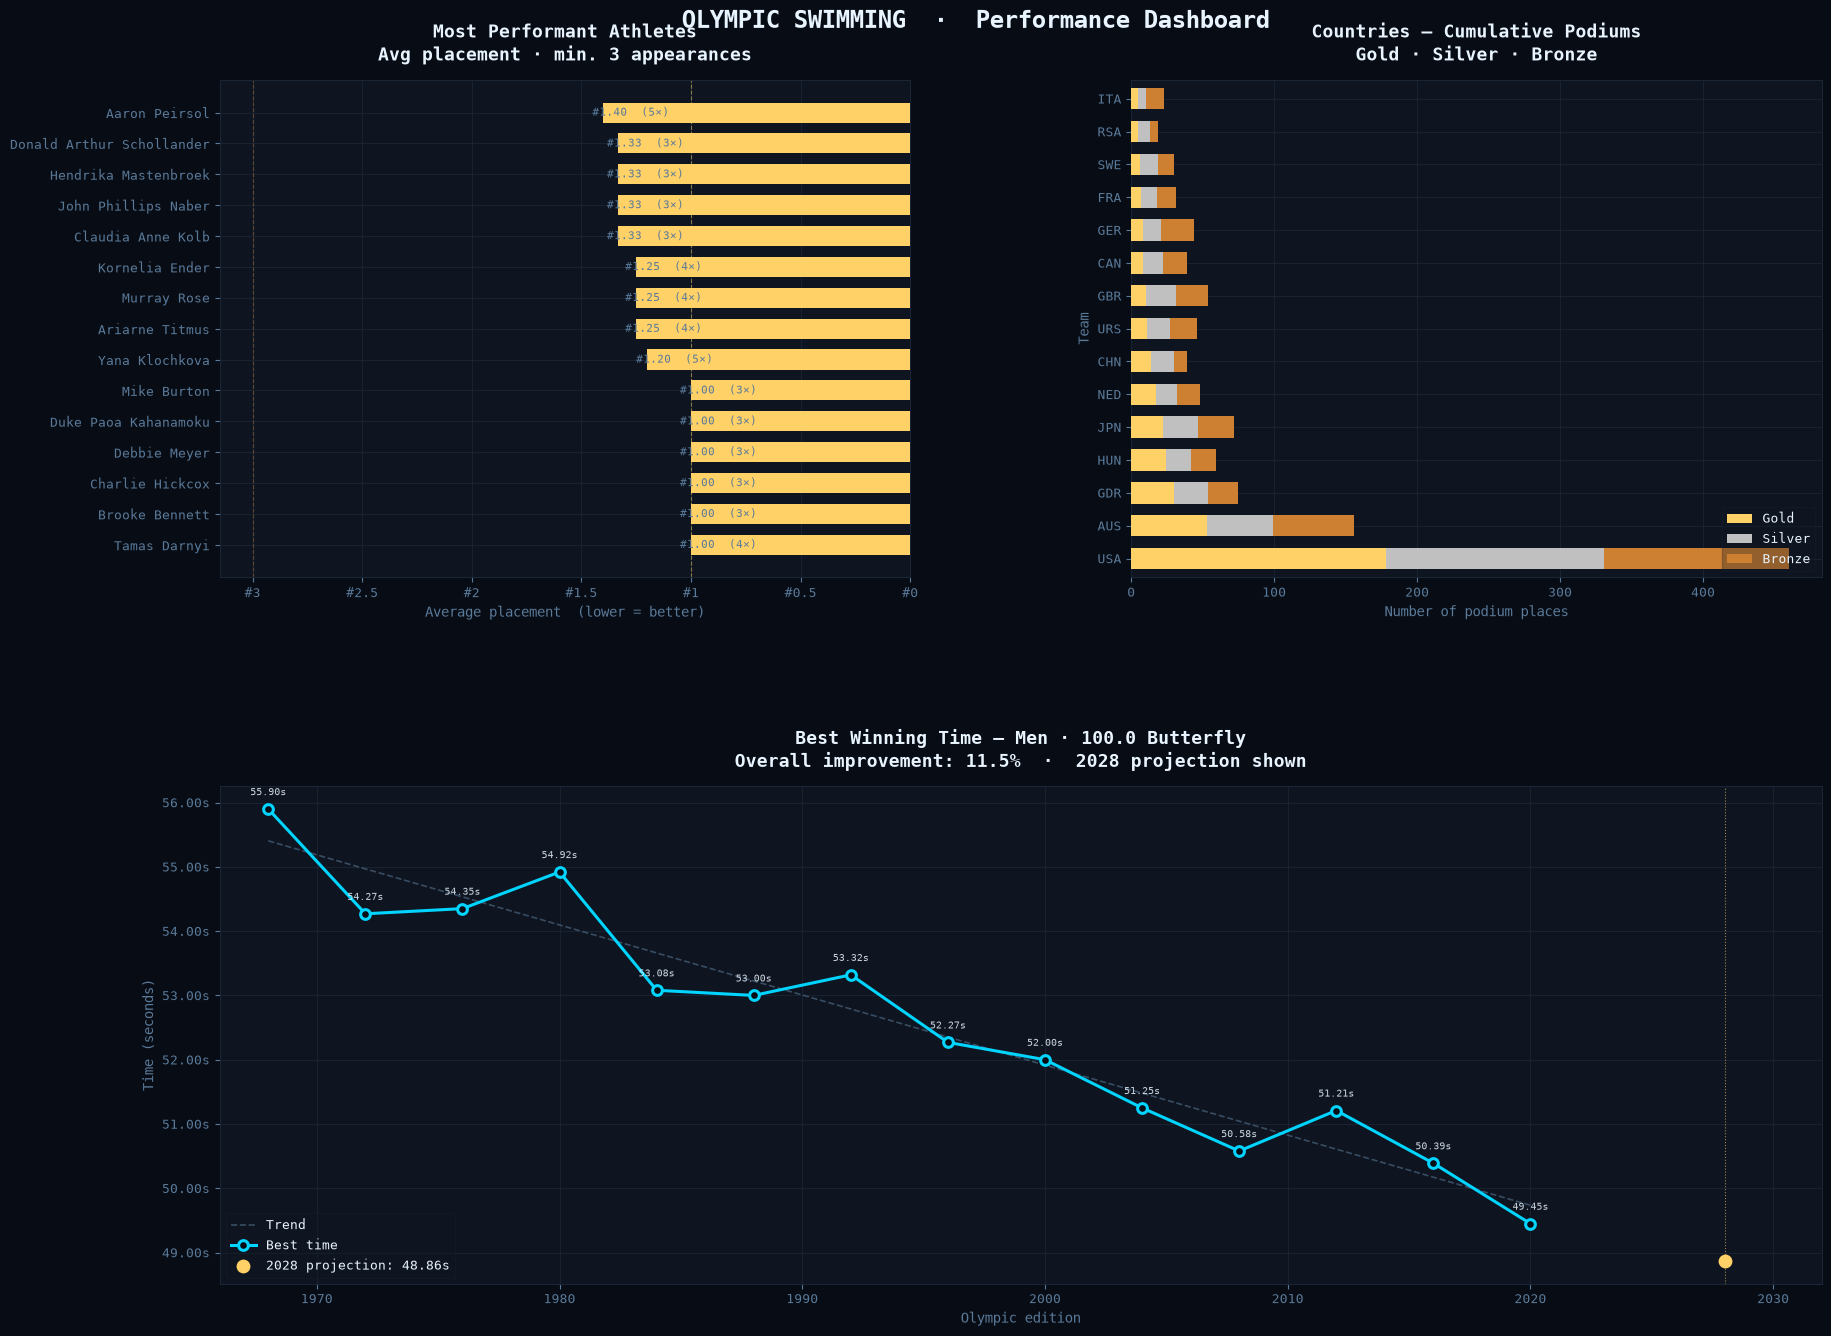

In [32]:
# graph atheletes
fig = plt.figure(figsize=(18, 14), facecolor=BG)
fig.suptitle("OLYMPIC SWIMMING  ·  Performance Dashboard",
                fontsize=17, fontweight="bold", color=TEXT,
                fontfamily="monospace", y=0.97)

gs = GridSpec(2, 2, figure=fig, hspace=0.42, wspace=0.32,
                left=0.08, right=0.97, top=0.92, bottom=0.06)

ax1 = fig.add_subplot(gs[0, 0])   # athletes
ax2 = fig.add_subplot(gs[0, 1])   # countries
ax3 = fig.add_subplot(gs[1, :])   # time evolution (full width)

print("\nBuilding charts...")
chart_athletes(ax1, df)
chart_countries(ax2, df)
chart_time_evolution(ax3, df)
plt.show()